# Model 3 - Fine-tuned (VGG16)

In [106]:
import keras
import matplotlib.pyplot as plt
import numpy as np
from keras import layers
from keras import models
from keras.models import Sequential
from keras.utils import image_dataset_from_directory
from scripts.notebook_scripts import collect_images, plot_images

This notebook experiments with a fine-tuned VGG16 model using the same image dataset as the previous notebooks.

The purpose of this experiment is to compare the models results with our previous two models and determine, if the generalization improves or deteriorates.

## Preparations

First, we load our data from their respective directories and assign their:
- image size (224 x 224)
- batch size
- labels

Now our data is split correctly and ready to be used!

In [88]:
batch_size = 32
img_size = (224, 224) # every image is 224x224 pixels

train_dataset = image_dataset_from_directory(
    "images/train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
 )

validation_dataset = image_dataset_from_directory(
    "images/validation",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
 )

test_dataset = image_dataset_from_directory(
    "images/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
 )

num_classes = len(train_dataset.class_names)

Found 175 files belonging to 5 classes.


Found 35 files belonging to 5 classes.
Found 40 files belonging to 5 classes.


We create the convolutional base of VGG16, which consisting of all convolutional and max-pooling layers, excluding the final fully connected (dense) classification layers.

At first, we set ``trainable`` = ``False`` to freeze the bottom layers, which means their parameters are not updated during training. During backpropagation, loss functions gradients still pass through the layer, but their weights don’t get updated.

In [89]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False)
conv_base.trainable = False

conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## Data Augmentation

In this sections we use the same data augmentation logic from our first CNN classifier for better consistency, when comparing results.

In [90]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),    # Randomly flip images horizontally
        layers.RandomRotation(0.2),         # Randomly rotate images by up to 20%
        layers.RandomZoom(0.2),             # Randomly zoom images by up to 20%
        layers.RandomTranslation(0.1, 0.1), # Randomly translate images by up to 10% in both directions
        layers.RandomBrightness(0.2),       # Randomly adjust brightness by up to 20%
        layers.RandomContrast(0.2),         # Randomly adjust contrast by up to 20%
    ]
)

## Frozen Model

In this step, we build a custom classifier on top of the pretrained VGG16 convolutional base.

**Overview:**

1. Input images are augmented to improve generalization.
2. VGG16 preprocessing is applied.
3. Data is passed through the convolutional base to detect high-level features.
4. Flatten converts the data into a 1D Vector.
5. Dense layer with `x` amount of units learns dataset specific patterns.
6. Dropout is used to reduce overfitting.
7. Output probabilities are calculated using `softmax`.

Here we only train the top layers while the base model stays frozen.

In [91]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

In [92]:
model = keras.Model(inputs, outputs)

## Training

The model is compiled using:
- Categorical crossentropy as its loss function
- RMSprop as optimizer
- Accuracy as the evaluation metric

In [93]:
opt = keras.optimizers.RMSprop()
model.compile(loss="categorical_crossentropy",
              optimizer=opt,
              metrics=["accuracy"])

model.summary()

Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 224, 224,  │          0 │ input_layer_27[0… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_36         │ (None, 224, 224)  │          0 │ sequential_7[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_37         │ (None, 224, 224)  │          0 │ sequential_7[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_38         │ (None, 224, 224)  │          0 │ sequential_7[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_12 (Stack)    │ (None, 224, 224,  │          0 │ get_item_36[0][0… │
│                     │ 3)                │            │ get_item_37[0][0… │
│                     │                   │            │ get_item_38[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 224, 224,  │          0 │ stack_12[0][0]    │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 25088)     │          0 │ vgg16[0][0]       │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 128)       │  3,211,392 │ flatten_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 128)       │          0 │ dense_29[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 5)         │        645 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,926,725 (68.39 MB)

 Trainable params: 3,212,037 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

We add ``ModelCheckpoint`` and ``EarlyStopping`` as callbacks during the training.

- ModelCheckpoint creates a separate checkpoint file where it saves weights at some intervals. From there the model and the weights can be loaded to continue training from the state saved.

- EarlyStopping monitors a predetermined metric during the training and stops the process if no improvement has occured for a number of epochs determined by `patience`.

In [94]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True)
]

In [95]:
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.3086 - loss: 37.3405 - val_accuracy: 0.7714 - val_loss: 3.6841
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.8000 - loss: 3.0252 - val_accuracy: 0.8571 - val_loss: 1.5426
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8286 - loss: 1.4960 - val_accuracy: 0.8857 - val_loss: 0.6970
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8400 - loss: 1.3155 - val_accuracy: 0.8857 - val_loss: 0.7775
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.8514 - loss: 1.0115 - val_accuracy: 0.9429 - val_loss: 0.2905
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8971 - loss: 0.7236 - val_accuracy: 0.8286 - val_loss: 0.7419
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.9143 - loss: 0.4000 - val_accuracy: 0.9143 - val_loss: 0.4710
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.8971 - loss: 0.3794 - val_accuracy: 0.8571 - val_loss: 0.8132
Epoch 9

## Visualization

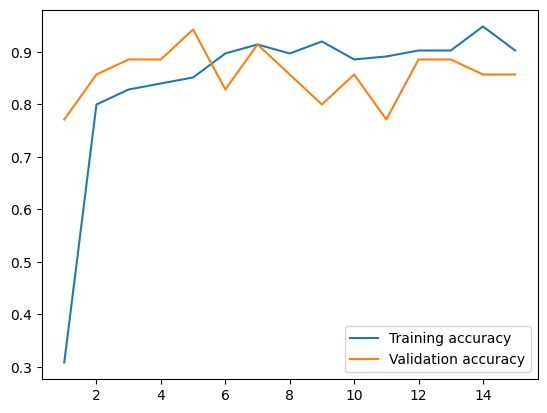

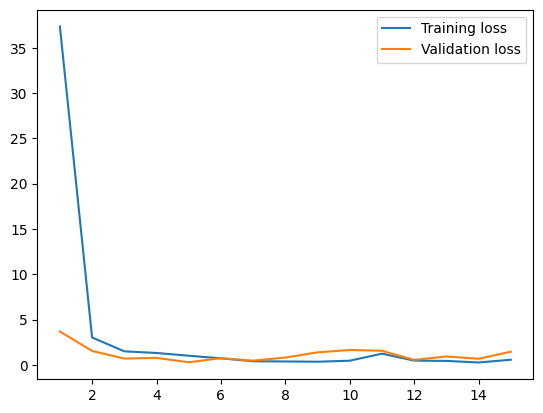

In [96]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = list(range(1, len(accuracy)+1))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.legend()
plt.show()

In [97]:
test_model = keras.models.load_model(
    "feature_extraction_with_data_augmentation.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:3f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 670ms/step - accuracy: 0.9000 - loss: 0.7092
Test accuracy: 0.900000


In [98]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

In [ ]:
finetuned_opt = keras.optimizers.RMSprop(learning_rate=1e-5)

model.compile(loss="categorical_crossentropy",
              optimizer=finetuned_opt,
              metrics=["accuracy"])

model.summary()

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss"),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True)
]

In [100]:
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.8686 - loss: 0.6526 - val_accuracy: 0.9714 - val_loss: 0.1576
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9200 - loss: 0.3173 - val_accuracy: 0.9714 - val_loss: 0.2640
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.9143 - loss: 0.4346 - val_accuracy: 0.9429 - val_loss: 0.2869
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.9200 - loss: 0.3819 - val_accuracy: 0.9714 - val_loss: 0.2457
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.9200 - loss: 0.4039 - val_accuracy: 0.9714 - val_loss: 0.2884
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.9143 - loss: 0.4986 - val_accuracy: 0.9714 - val_loss: 0.2712
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.9029 - loss: 0.3801 - val_accuracy: 0.9714 - val_loss: 0.3096
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.9314 - loss: 0.1757 - val_accuracy: 0.9714 - val_loss: 0.2966
Epoch 9/

In [129]:
test_model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:3f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 606ms/step - accuracy: 0.9500 - loss: 0.6402
Test accuracy: 0.950000


In [128]:
num = len(test_dataset.file_paths)
print(f"\nNumber of pictures in test_dataset: {num}")
print(f"Ratio of predictions: {np.rint(num * test_acc)} : {np.rint(num - (num * test_acc))}")


Number of pictures in test_dataset: 40
Ratio of predictions: 38.0 : 2.0


2
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


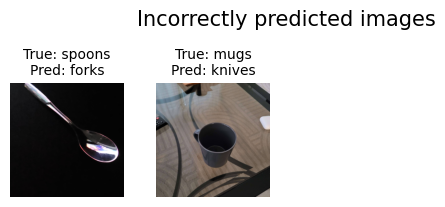

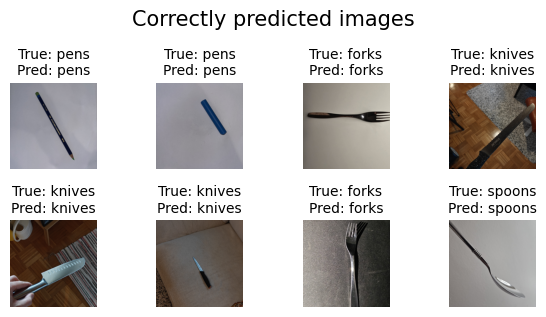

In [ ]:
correct_images, wrong_images = collect_images(test_dataset, model)

plot_images(wrong_images, "Incorrectly predicted images")
plot_images(correct_images, "Correctly predicted images")